In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## Decision Tree

### Cell 1: 라이브러리 및 데이터 로드

In [3]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()
# ---------------------------------------------------------
# [추가됨] 2.5 도메인 지식 기반 파생 변수 (Feature Engineering)
# 로봇이 멈춰있는 상태(Speed=0)를 트리가 명시적으로 알 수 있도록 이진 변수 추가
# 미세한 센서 노이즈를 고려하여, 6개 관절 속도 절대값의 합이 0.05 미만이면 정지(1)로 간주
# ---------------------------------------------------------
speed_cols = ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']
df_clean['is_stationary'] = (df_clean[speed_cols].abs().sum(axis=1) < 0.05).astype(int)
# 3. 입력 피처(X) 및 타겟(y) 설정 (파생 변수 포함)
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
    'is_stationary'  # 새롭게 만든 파생 변수를 학습 피처로 추가
]
X = df_clean[input_cols]
y = df_clean['Tool_current']
print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개, 타겟: Tool_current")

데이터 크기: (7355, 25)
피처 개수: 13개, 타겟: Tool_current


### Cell 2: Train/Test Split (교차 검증을 위한 준비)

In [4]:
# 1. 80:20으로 Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 결정 트리(Tree 기반 모델)는 거리 기반 알고리즘이 아니므로 
# StandardScaler나 MinMaxScaler와 같은 스케일링이 필수는 아닙니다.
# 따라서 스케일링 단계는 생략하고 원본 데이터를 그대로 사용합니다.

print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

학습 데이터 크기: (5884, 13)
테스트 데이터 크기: (1471, 13)


### Cell 3: Decision Tree 모델 K-Fold 교차검증 및 하이퍼파라미터 튜닝

In [5]:
# 1. 교차 검증 (K-Fold) 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Decision Tree Regressor 기본 모델 생성
dt_reg = DecisionTreeRegressor(random_state=42)

# 3. 튜닝할 하이퍼파라미터 그리드 설정
# - max_depth: 트리의 최대 깊이 (과적합 방지)
# - min_samples_split: 노드를 분할하기 위한 최소 샘플 수
# - min_samples_leaf: 리프 노드가 되기 위한 최소 샘플 수
param_grid = {
    #'max_depth': [None, 5, 10, 15, 20],
    #'min_samples_split': [2, 10, 20],
    #'min_samples_leaf': [1, 5, 10]
    #'max_depth' : [4, 5, 6, 7, 8, 9, 10],       # 오버피팅을 막기 위해 나무 깊이를 적절히 제한
    #'min_samples_split': [4, 6, 7, 8, 10],
    #'min_samples_split': [10, 20, 30], 
    #'min_samples_leaf': [4, 5, 6, 7, 8],     # 리프 노드의 최소 샘플 수를 키워 규제 적용
    #'min_samples_leaf': [5, 10, 15, 20] 
    
    'max_depth': [5, 6, 7, 8],
    'min_samples_leaf': [7, 10, 15, 20, 30],  # 리프 노드 제한 범위를 더 넓혀봄
    'min_samples_split': [10, 20, 25, 30]
}

# 4. GridSearchCV 실행 (R² 기준으로 최적 파라미터 탐색)
print("--- Decision Tree 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search = GridSearchCV(
    estimator=dt_reg, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 5. 최적 모델 및 결과 확인
best_dt = grid_search.best_estimator_

print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search.best_params_.items():
    print(f"  • {param}: {value}")
print("")
print(f"최고 교차 검증 R² 점수: {grid_search.best_score_:.4f}")

--- Decision Tree 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 80 candidates, totalling 400 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • max_depth: 8
  • min_samples_leaf: 7
  • min_samples_split: 20

최고 교차 검증 R² 점수: 0.4256


### Cell 4: 최종 테스트 데이터 평가

In [6]:
# 1. GridSearchCV 결과에서 상위 5개 모델 추출
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []

print("--- [모델 비교] 상위 10개 Decision Tree 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_r2 = row['mean_test_score']
    
    # 해당 파라미터로 모델 재학습
    model = DecisionTreeRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # 평가지표 계산
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # 파라미터 설정을 간소화된 문자열로 변환 (예: D=7, L=7, S=20)
    # D: max_depth, L: min_samples_leaf, S: min_samples_split
    depth = params.get('max_depth', 'None')
    leaf = params.get('min_samples_leaf', '-')
    split = params.get('min_samples_split', '-')
    param_short = f"D={depth}, L={leaf}, S={split}"
    
    # 결과 저장 (과적합 정도를 보기 위해 Gap 추가)
    comparison_data.append({
        '순위': rank,
        'CV R²': round(cv_r2, 4),
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        '과적합 Gap': round(train_r2 - test_r2, 4), # Train과 Test의 차이
        'Train MSE': round(mean_squared_error(y_train, y_train_pred), 6),
        'Test MSE': round(mean_squared_error(y_test, y_test_pred), 6),
        '파라미터 설정': param_short
    })

# 3. 비교 결과를 데이터프레임으로 출력 (가독성 향상)
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df) # Jupyter Notebook 환경에서는 표 형태로 예쁘게 출력됩니다. (터미널이면 print(comparison_df) 사용)


print("\n" + "="*50)
print("--- [상세 분석] 1위 최적 모델 최종 평가지표 ---")
print("="*50)

# (기존 작성하신 코드 유지 - 1위 모델 상세 지표 출력)
best_dt = grid_search.best_estimator_
y_train_pred_best = best_dt.predict(X_train)
y_test_pred_best = best_dt.predict(X_test)

def print_metrics(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"R² (결정계수) : {r2:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")

print_metrics(y_train, y_train_pred_best, "Train")
print_metrics(y_test, y_test_pred_best, "Test")

--- [모델 비교] 상위 10개 Decision Tree 성능 종합 ---


,순위,CV R²,Train R²,Test R²,과적합 Gap,Train MSE,Test MSE,파라미터 설정
0,1,0.4256,0.6253,0.4442,0.1810,0.002395,0.003052,"D=8, L=7, S=20"
1,2,0.4192,0.5163,0.3624,0.1539,0.003092,0.003501,"D=8, L=30, S=25"
2,2,0.4192,0.5163,0.3624,0.1539,0.003092,0.003501,"D=8, L=30, S=20"
3,2,0.4192,0.5163,0.3624,0.1539,0.003092,0.003501,"D=8, L=30, S=10"
4,2,0.4192,0.5163,0.3624,0.1539,0.003092,0.003501,"D=8, L=30, S=30"
5,6,0.4169,0.6397,0.4697,0.1700,0.002303,0.002912,"D=8, L=7, S=10"
6,7,0.4168,0.5990,0.4201,0.1789,0.002563,0.003185,"D=7, L=7, S=20"
7,8,0.4164,0.5567,0.4273,0.1294,0.002833,0.003145,"D=6, L=7, S=20"
8,9,0.4150,0.5586,0.4342,0.1244,0.002821,0.003108,"D=6, L=7, S=10"
9,10,0.4149,0.6089,0.4391,0.1698,0.002500,0.003081,"D=7, L=7, S=10"



--- [상세 분석] 1위 최적 모델 최종 평가지표 ---

[Train 데이터 평가]
R² (결정계수) : 0.6253
MSE  : 0.002395
RMSE : 0.048939
MAE  : 0.018936

[Test 데이터 평가]
R² (결정계수) : 0.4442
MSE  : 0.003052
RMSE : 0.055246
MAE  : 0.021223


### Cell 5: 피처 중요도 (Feature Importance) 및 시각화

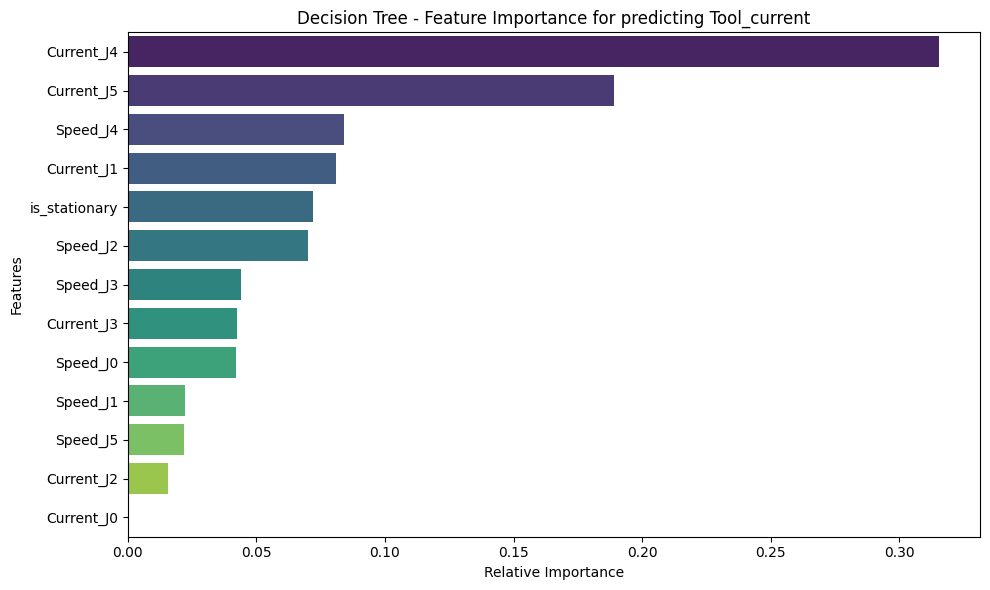

가장 중요한 피처 상위 3개:
   Feature  Importance
Current_J4    0.315619
Current_J5    0.189089
  Speed_J4    0.084076


In [7]:
# 1. Feature Importance 추출
feature_importances = best_dt.feature_importances_
importance_df = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 2. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree - Feature Importance for predicting Tool_current')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 가장 중요한 상위 3개 피처 출력
print("가장 중요한 피처 상위 3개:")
print(importance_df.head(3).to_string(index=False))

### Cell 6: 실제값 vs 예측값 산점도 시각화

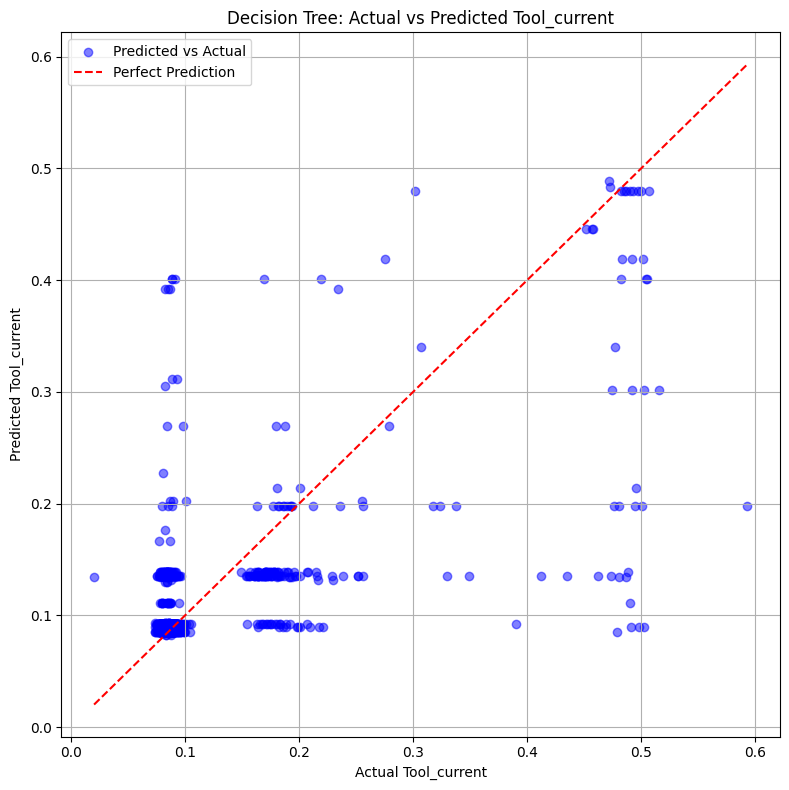

In [8]:
# 선형 회귀와 달리 비선형 관계를 잘 잡았는지 눈으로 확인하는 산점도입니다.
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue', label='Predicted vs Actual')

# 완벽하게 예측했을 때의 대각선 (y=x)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title('Decision Tree: Actual vs Predicted Tool_current')
plt.xlabel('Actual Tool_current')
plt.ylabel('Predicted Tool_current')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Cell 7: 결정 경계(Decision Boundary) 시각화

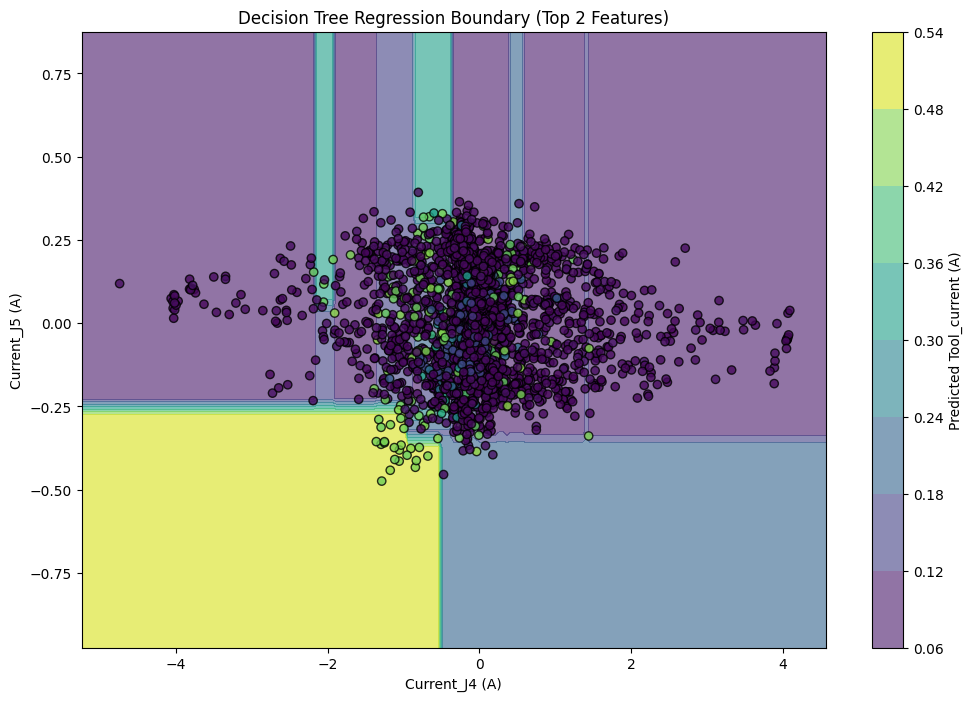

In [9]:
# 1. 2D 시각화를 위해 가장 중요한 두 개의 피처만 선택
feature_x = 'Current_J4'
feature_y = 'Current_J5'

X_train_2d = X_train[[feature_x, feature_y]]

# 2. 시각화 전용 모델 학습 (최적 하이퍼파라미터 적용)
# 2차원 공간만 나누는 것을 보기 위해 시각화 전용 트리를 만듭니다.
dt_2d = DecisionTreeRegressor(max_depth=7, min_samples_leaf=7, min_samples_split=10, random_state=42)
dt_2d.fit(X_train_2d, y_train)

# 3. 그래프의 배경(Meshgrid) 촘촘하게 만들기
x_min, x_max = X_train_2d[feature_x].min() - 0.5, X_train_2d[feature_x].max() + 0.5
y_min, y_max = X_train_2d[feature_y].min() - 0.5, X_train_2d[feature_y].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# 4. 배경의 각 포인트에 대해 모델 예측값 계산
Z = dt_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. 결정 경계 시각화
plt.figure(figsize=(12, 8))

# 배경 색상: 모델의 예측값 (진한 색일수록 그리퍼 전류가 높음)
contour = plt.contourf(xx, yy, Z, alpha=0.6, cmap='viridis')
plt.colorbar(contour, label='Predicted Tool_current (A)')

# 실제 데이터 포인트 산점도 (실제 정답)
scatter = plt.scatter(X_train_2d[feature_x], X_train_2d[feature_y], c=y_train, 
                      edgecolors='k', cmap='viridis', marker='o', alpha=0.8)

plt.xlabel(f'{feature_x} (A)')
plt.ylabel(f'{feature_y} (A)')
plt.title(f'Decision Tree Regression Boundary (Top 2 Features)')
plt.grid(False)
plt.show()

### Cell 8: 의사결정나무 시각화

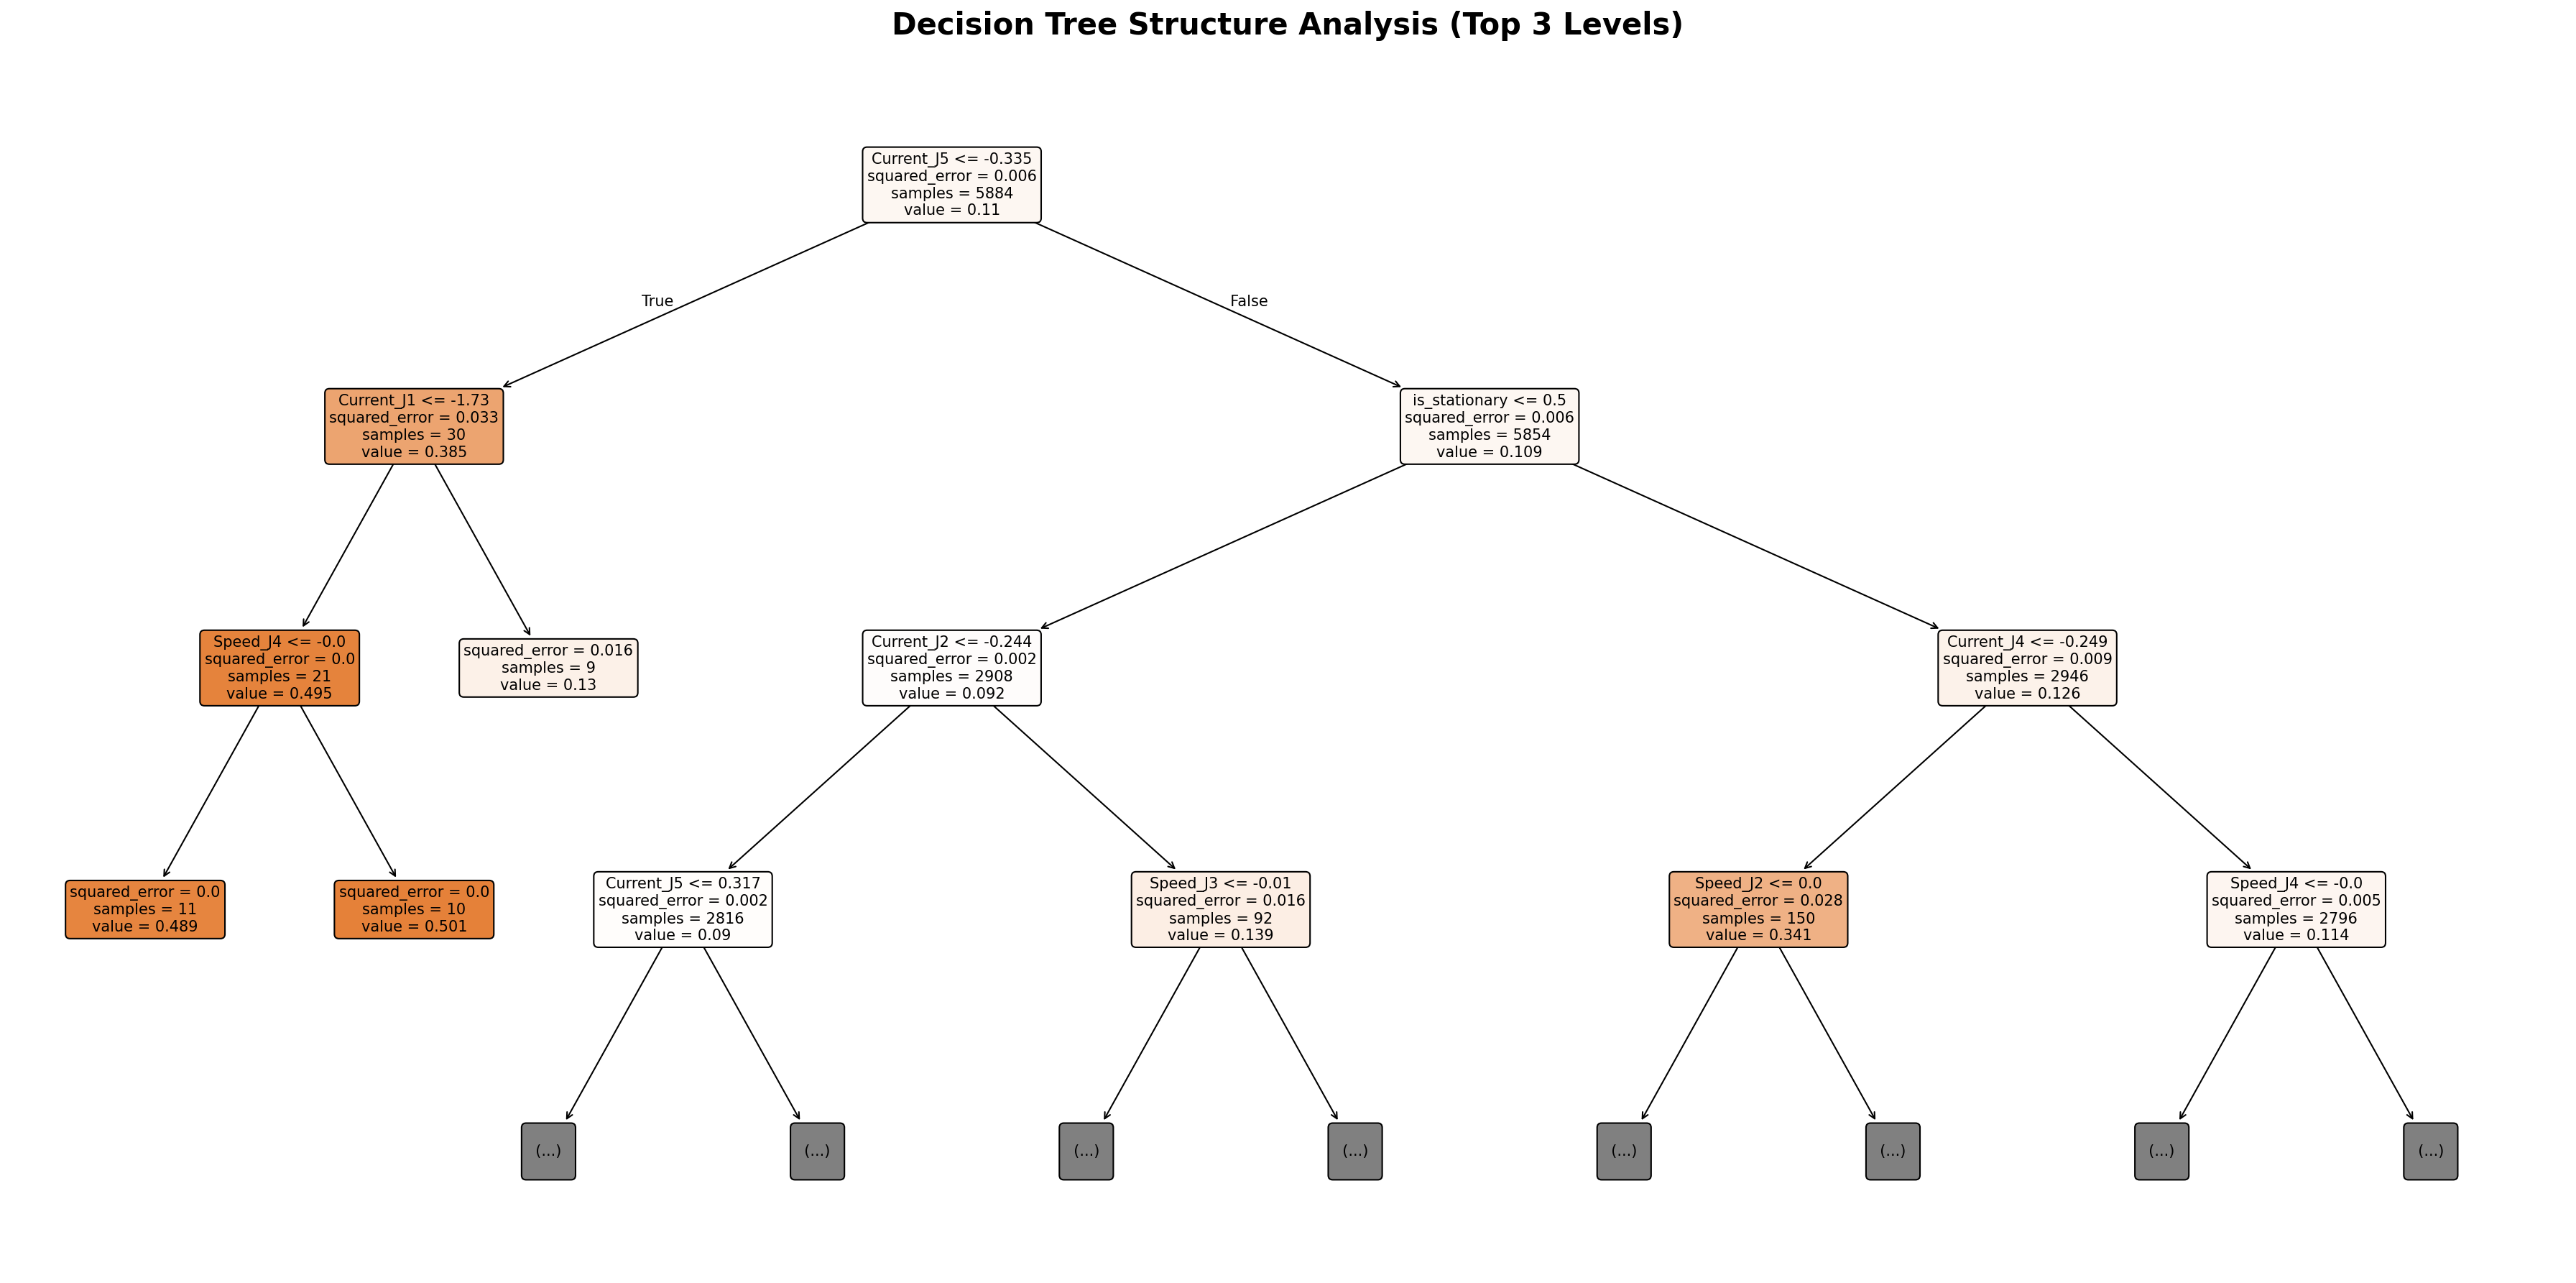

In [10]:
from sklearn.tree import plot_tree

# 1. 그래프 크기 설정 (노드가 크므로 가로로 길고 시원하게 설정합니다)
plt.figure(figsize=(24, 12), dpi=150)  # dpi를 높이면 저장 시 이미지가 깨지지 않습니다.

# 2. plot_tree 실행
plot_tree(
    best_dt, 
    max_depth=3,               # [중요] 상위 3단계까지만 그려 가독성을 확보합니다 (전체 확인을 원하시면 이 줄을 삭제하세요)
    feature_names=input_cols,  # [매우 중요] X[0], X[1] 대신 실제 변수명(Current_J4 등)이 표기됩니다.
    filled=True,               # 예측값(Tool_current)의 크기에 따라 노드에 색상이 알록달록하게 채워집니다.
    rounded=True,              # 노드 박스 모서리를 둥글게 만들어 가독성을 높입니다.
    fontsize=10                # 박스 안의 글자 크기 조정
)

# 3. 타이틀 설정 및 이미지 파일로 저장
plt.title("Decision Tree Structure Analysis (Top 3 Levels)", fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()

# 보고서 한글 작성을 위해 바로 복사해서 붙여넣을 수 있도록 이미지로 저장해둡니다.
plt.savefig("decision_tree_structure.png", bbox_inches='tight', dpi=300)
plt.show()

## Random Forest

### Cell 1: 라이브러리 및 데이터 로드

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# ---------------------------------------------------------
# [추가됨] 2.5 도메인 지식 기반 파생 변수 (Feature Engineering)
# 로봇이 멈춰있는 상태(Speed=0)를 트리가 명시적으로 알 수 있도록 이진 변수 추가
# ---------------------------------------------------------
speed_cols = ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']
df_clean['is_stationary'] = (df_clean[speed_cols].abs().sum(axis=1) < 0.05).astype(int)
# 3. 입력 피처(X) 및 타겟(y) 설정 (파생 변수 포함)
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
    'is_stationary'  # 새롭게 만든 파생 변수를 학습 피처로 추가
]
#input_cols = [
#    'Current_J4', 'is_stationary', 'Current_J5', 'Current_J0', 'Speed_J2'
#]

X = df_clean[input_cols]
y = df_clean['Tool_current']

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개, 타겟: Tool_current")

데이터 크기: (7355, 25)
피처 개수: 13개, 타겟: Tool_current


### Cell 2: Train/Test Split

In [93]:
# 1. 80:20으로 Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest 역시 Decision Tree의 앙상블이므로 
# 거리 계산을 하지 않아 스케일링(StandardScaler 등)이 필요하지 않습니다.

print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

학습 데이터 크기: (5884, 13)
테스트 데이터 크기: (1471, 13)


### Cell 3: Random Forest K-Fold 교차검증 및 다각도 하이퍼파라미터 튜닝

In [94]:
# 1. 교차 검증 (K-Fold) 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Random Forest Regressor 기본 모델 생성
# 병렬 처리(n_jobs=-1)를 추가하여 내부 트리 학습을 가속화합니다.
rf_reg = RandomForestRegressor(random_state=42)

# 3. 튜닝할 하이퍼파라미터 그리드 설정 (Decision Tree 탐색 결과 참고)
param_grid = {
    'n_estimators': [100],             # 트리의 개수
    #'max_depth': [10, 15, 20],              # 트리의 최대 깊이 (오버피팅 방지)
    #'min_samples_leaf': [2, 5, 10],         # 리프 노드가 되기 위한 최소 샘플 수
    #'min_samples_split': [5, 10, 20]        # 노드를 분할하기 위한 최소 샘플 수
    
    #'max_depth': [6, 8, 10, 12],            # 기존 20 -> 12 이하로 대폭 축소
    #'min_samples_leaf': [10, 12],   # 리프 노드 제한 범위를 더 넓혀봄
    #'min_samples_split': [10, 20, 25],
    #'max_features': ['sqrt', 0.5, 0.7, 1.0]
    # 기존 12가 최고였으므로 상한선을 열어줌 (과적합 주의하며 12, 14, 16 탐색)
    #'max_depth': [10, 12], 
    
    # 기존 10이 최고였으므로 더 작은 리프 노드를 허용해봄 (성능 향상 목적)
    #'min_samples_leaf': [10,12], 
    
    # 리프 노드가 작아지므로 split도 같이 낮춰서 탐색
    #'min_samples_split': [ 10, 20, 25], 
    
    # 기존에 0.5가 가장 좋았으므로, 그 주변을 집중 탐색
    #'max_features': [0.4, 0.5, 0.6, 0.7]
    #'max_depth': [9,10,11], 
    #'min_samples_leaf': [9,10,11], 
    #'min_samples_split': [10], 
    'max_features': [0.4, 0.5],  
    # 최대 특성 수는 0.4 ~ 0.5가 모든 표에서 가장 결과가 좋습니다. 고정해도 무방합니다.
    #'max_features': [0.4, 0.5], 
    
    # 깊이는 성능을 위해 12~16 범위로 열어둡니다.
    'max_depth': [10,12,14], 
    
    # [핵심] L값을 3(과적합)과 8(안정) 사이에서 집중 탐색합니다.
    'min_samples_leaf': [10,12,14,15], 
    
    # L에 맞춰 S값도 적당히 조절합니다.
    'min_samples_split': [10] 
}

# 4. GridSearchCV 실행 (R² 기준으로 최적 파라미터 탐색)
print("--- Random Forest 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search_rf = GridSearchCV(
    estimator=rf_reg, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='r2', 
    n_jobs=-1,  # CPU의 모든 코어를 사용하여 탐색 속도 대폭 상승
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

# 5. 최적 모델 및 결과 확인
best_rf = grid_search_rf.best_estimator_

print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search_rf.best_params_.items():
    print(f"  • {param}: {value}")
print("")
print(f"최고 교차 검증 R² 점수: {grid_search_rf.best_score_:.4f}")

--- Random Forest 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • max_depth: 12
  • max_features: 0.4
  • min_samples_leaf: 10
  • min_samples_split: 10
  • n_estimators: 100

최고 교차 검증 R² 점수: 0.5488


### Cell 4: 하이퍼파라미터 조합별 R² 순위 확인 (Top 10)

In [95]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_rf_df = pd.DataFrame(grid_search_rf.cv_results_)
top_models_rf = cv_results_rf_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data_rf = []

print("--- [모델 비교] 상위 10개 Random Forest 성능 종합 ---")
print("(Random Forest는 무거워 재학습에 시간이 약간 소요될 수 있습니다)")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models_rf.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_r2 = row['mean_test_score']
    
    # 해당 파라미터로 모델 재학습
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # 평가지표 계산
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # 파라미터 설정을 간소화된 문자열로 변환 (예: N=100, D=15, L=5, S=10)
    # N: n_estimators, D: max_depth, L: min_samples_leaf, S: min_samples_split
    #n_est = params.get('n_estimators', '-')
    depth = params.get('max_depth', 'None')
    leaf = params.get('min_samples_leaf', '-')
    split = params.get('min_samples_split', '-')
    max_features = params.get('max_features', '-')
    param_short = f"D={depth}, L={leaf}, S={split}, M={max_features}"
    
    # 결과 저장 (과적합 정도를 보기 위해 Gap 추가)
    comparison_data_rf.append({
        '순위': rank,
        'CV R²': round(cv_r2, 4),
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        '과적합 Gap': round(train_r2 - test_r2, 4), # Train과 Test의 차이
        'Train MSE': round(mean_squared_error(y_train, y_train_pred), 6),
        'Test MSE': round(mean_squared_error(y_test, y_test_pred), 6),
        '파라미터 설정': param_short
    })

# 3. 비교 결과를 데이터프레임으로 출력 (가독성 향상)
comparison_df_rf = pd.DataFrame(comparison_data_rf)
display(comparison_df_rf) 


print("\n" + "="*50)
print("--- [상세 분석] 1위 최적 모델 최종 평가지표 ---")
print("="*50)

y_train_pred_best_rf = best_rf.predict(X_train)
y_test_pred_best_rf = best_rf.predict(X_test)

def print_metrics_rf(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"R² (결정계수) : {r2:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")

print_metrics_rf(y_train, y_train_pred_best_rf, "Train")
print_metrics_rf(y_test, y_test_pred_best_rf, "Test")

--- [모델 비교] 상위 10개 Random Forest 성능 종합 ---
(Random Forest는 무거워 재학습에 시간이 약간 소요될 수 있습니다)


,순위,CV R²,Train R²,Test R²,과적합 Gap,Train MSE,Test MSE,파라미터 설정
0,1,0.5488,0.6788,0.5315,0.1473,0.002053,0.002573,"D=12, L=10, S=10, M=0.4"
1,2,0.5483,0.6826,0.5369,0.1457,0.002028,0.002543,"D=14, L=10, S=10, M=0.4"
2,3,0.5468,0.6863,0.5387,0.1476,0.002005,0.002534,"D=14, L=10, S=10, M=0.5"
3,4,0.5464,0.6836,0.5349,0.1487,0.002022,0.002554,"D=12, L=10, S=10, M=0.5"
4,5,0.5453,0.6567,0.5165,0.1402,0.002194,0.002655,"D=12, L=12, S=10, M=0.4"
5,6,0.5449,0.6676,0.5264,0.1412,0.002124,0.002601,"D=10, L=10, S=10, M=0.4"
6,7,0.5435,0.6609,0.5250,0.1359,0.002167,0.002608,"D=14, L=12, S=10, M=0.4"
7,8,0.5418,0.6715,0.5202,0.1513,0.002099,0.002635,"D=10, L=10, S=10, M=0.5"
8,9,0.5384,0.6623,0.5199,0.1424,0.002159,0.002637,"D=12, L=12, S=10, M=0.5"
9,10,0.5374,0.6508,0.5178,0.1330,0.002232,0.002648,"D=10, L=12, S=10, M=0.4"



--- [상세 분석] 1위 최적 모델 최종 평가지표 ---

[Train 데이터 평가]
R² (결정계수) : 0.6788
MSE  : 0.002053
RMSE : 0.045310
MAE  : 0.018182

[Test 데이터 평가]
R² (결정계수) : 0.5315
MSE  : 0.002573
RMSE : 0.050726
MAE  : 0.020436


### Cell 5: 최적의 Random Forest 모델로 최종 테스트 평가

In [96]:
# 1. 1등을 차지한 최적 모델로 Train/Test 예측
y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

# 2. 평가지표 계산 함수
def print_metrics_rf(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"R² (결정계수) : {r2:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")

print("--- [최종 결과] Random Forest Regressor (Tuned) ---")
print_metrics_rf(y_train, y_train_pred_rf, "Train")
print_metrics_rf(y_test, y_test_pred_rf, "Test")

# R² 점수가 Train과 Test에서 어떻게 차이나는지(과적합 정도) 확인하세요.

--- [최종 결과] Random Forest Regressor (Tuned) ---

[Train 데이터 평가]
R² (결정계수) : 0.6788
MSE  : 0.002053
RMSE : 0.045310
MAE  : 0.018182

[Test 데이터 평가]
R² (결정계수) : 0.5315
MSE  : 0.002573
RMSE : 0.050726
MAE  : 0.020436


### Cell 6: 피처 중요도 (Feature Importance) 시각화

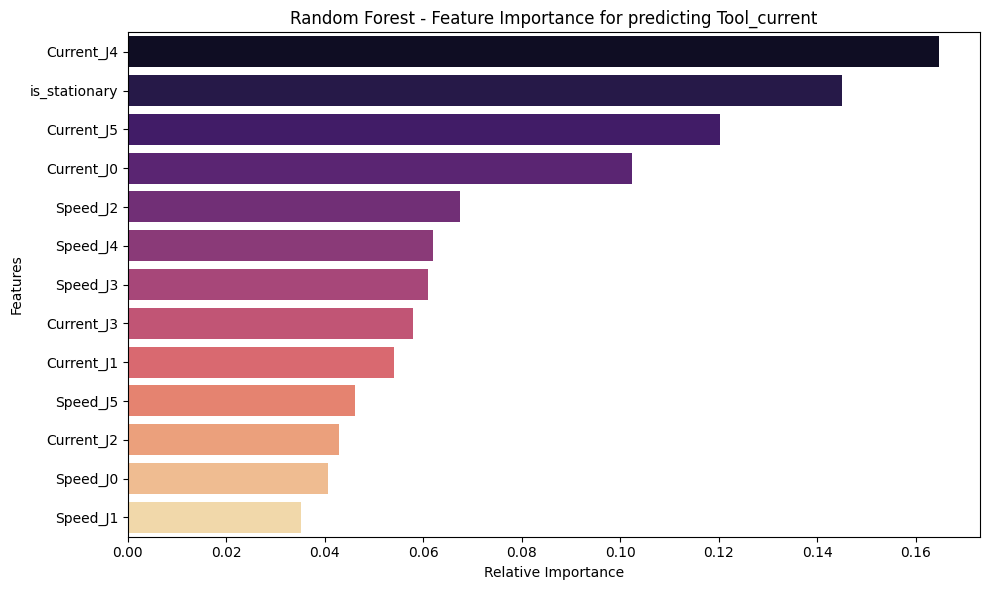

가장 중요한 피처 상위 3개:
      Feature  Importance
   Current_J4    0.164819
is_stationary    0.145120
   Current_J5    0.120229


In [97]:
# 1. Random Forest의 Feature Importance 추출
feature_importances_rf = best_rf.feature_importances_
importance_df_rf = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances_rf
}).sort_values(by='Importance', ascending=False)

# 2. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf, palette='magma')
plt.title('Random Forest - Feature Importance for predicting Tool_current')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 가장 중요한 상위 3개 피처 출력
print("가장 중요한 피처 상위 3개:")
print(importance_df_rf.head(3).to_string(index=False))

### Cell 7: 실제값 vs 예측값 산점도

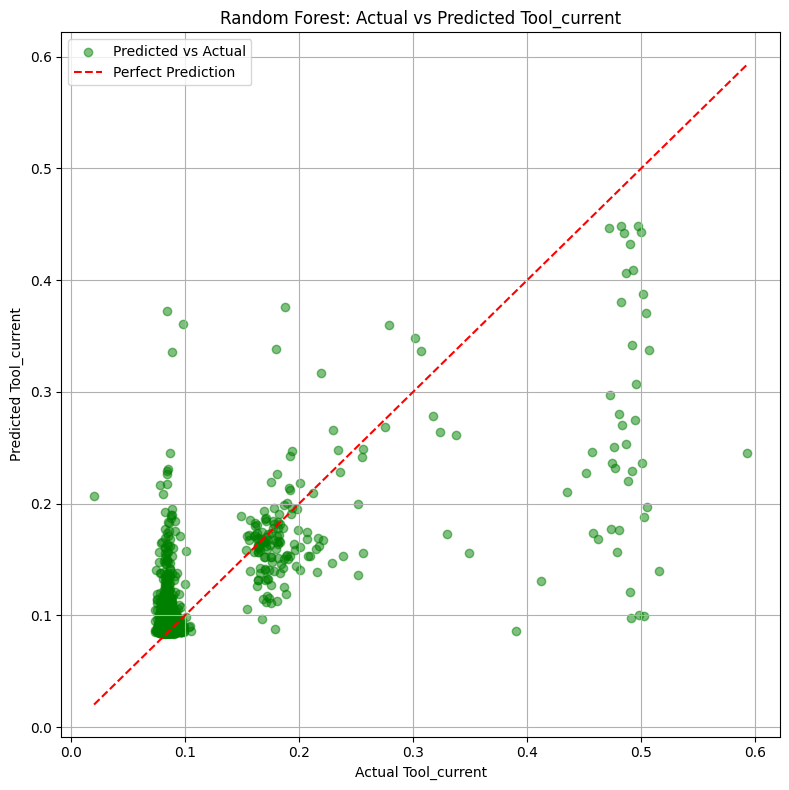

In [98]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, color='green', label='Predicted vs Actual')

# 완벽하게 예측했을 때의 대각선 (y=x)
min_val = min(y_test.min(), y_test_pred_rf.min())
max_val = max(y_test.max(), y_test_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title('Random Forest: Actual vs Predicted Tool_current')
plt.xlabel('Actual Tool_current')
plt.ylabel('Predicted Tool_current')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()